## ۱) بررسی محیط


In [47]:
import os, torch

# Only GPU 0 of the two T4s — per the spec, start with a single GPU.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (torch build):", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

DEVICE = "cuda:0"
DTYPE = torch.float16

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version (torch build): 12.8
GPU: Tesla T4
Total VRAM (GB): 15.6


## ۲) نصب کتابخانه‌ها


In [48]:
import subprocess, sys

# نسخه‌های پین‌شده — همون ترکیب تأییدشده‌ای که نوت‌بوک اصلی پروژه استفاده می‌کنه.
# diffusers>=0.31.0 (بدون سقف) آخرین نسخه رو می‌گرفت که با نسخهٔ پیش‌فرض
# huggingface_hub ناسازگار بود (pip warning: dependency conflict).
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "diffusers==0.37.0", "transformers==4.57.6", "accelerate==1.12.0", "safetensors", "huggingface_hub"
])
print(" Libraries installed (torch untouched)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 27.9 MB/s eta 0:00:00
 Libraries installed (torch untouched)


## ۳) آپلود عکس اتاق + تنظیمات پرامپت (اختیاری، عوضش کنی می‌تونی)

In [49]:
import ipywidgets as widgets
from IPython.display import display

single_uploader = widgets.FileUpload(accept="image/*", multiple=False, description="انتخاب عکس اتاق")
display(single_uploader)

FileUpload(value=(), accept='image/*', description='انتخاب عکس اتاق')

عکس رو که انتخاب کردی، سلول بعدی رو اجرا کن تا لودش کنه.

In [50]:
from PIL import Image
import io

items = list(single_uploader.value.values()) if isinstance(single_uploader.value, dict) else list(single_uploader.value)
if not items:
    print(" هنوز عکسی انتخاب نکردی — برگرد سلول قبل و انتخاب کن")
else:
    f = items[0]
    content = f["content"] if isinstance(f, dict) else f.content
    original_image = Image.open(io.BytesIO(bytes(content))).convert("RGB")
    print("Input size:", original_image.size)

Input size: (643, 476)


In [51]:
PROMPT = (
    "modern scandinavian interior design, warm oak wood tones, soft neutral palette, "
    "natural daylight, cozy textiles, minimalist decor, photorealistic, interior photography, "
    "8k, highly detailed, architectural digest style"
)
NEGATIVE_PROMPT = (
    "different room layout, moved walls, moved windows, changed camera angle, "
    "blurry, low quality, distorted, watermark, text, oversaturated, cartoon"
)

SEED = None  

## ۴) استخراج نقشهٔ عمق


In [52]:
import gc
import numpy as np
import torch.nn.functional as F
from transformers import DPTImageProcessor, DPTForDepthEstimation


def resize_to_multiple_of_8(w, h, max_side=1024):
    """Preserve the input aspect ratio, capped at max_side on the long edge,
    rounded to a multiple of 8 (SDXL requirement)."""
    scale = max_side / max(w, h)
    new_w, new_h = round(w * scale), round(h * scale)
    new_w -= new_w % 8
    new_h -= new_h % 8
    return max(new_w, 8), max(new_h, 8)


GEN_W, GEN_H = resize_to_multiple_of_8(*original_image.size)
print(f"Generation size (aspect-preserved): {GEN_W}x{GEN_H}")

_depth_processor = DPTImageProcessor.from_pretrained("Intel/dpt-hybrid-midas")
_depth_model = DPTForDepthEstimation.from_pretrained(
    "Intel/dpt-hybrid-midas", torch_dtype=torch.float32  # small model, fp32 is fine and avoids precision issues
).to(DEVICE)
_depth_model.eval()

_inputs = _depth_processor(images=original_image, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    _pred = _depth_model(**_inputs).predicted_depth

_depth = F.interpolate(
    _pred.unsqueeze(1), size=(GEN_H, GEN_W), mode="bicubic", align_corners=False
)
_dmin, _dmax = torch.amin(_depth), torch.amax(_depth)
_depth = (_depth - _dmin) / (_dmax - _dmin + 1e-8)
_depth_rgb = torch.cat([_depth] * 3, dim=1)[0].permute(1, 2, 0).cpu().numpy()
depth_map = Image.fromarray((_depth_rgb * 255.0).clip(0, 255).astype(np.uint8))

# ── Free the depth model before loading the (much bigger) generation pipeline ──
del _depth_model, _depth_processor, _inputs, _pred, _depth, _depth_rgb
gc.collect()
torch.cuda.empty_cache()
print(f" Depth map extracted ({depth_map.size}); depth model unloaded, VRAM freed")
print("VRAM allocated right now (GB):", round(torch.cuda.memory_allocated() / 1e9, 2))

Generation size (aspect-preserved): 1024x752


preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/490M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/490M [00:00<?, ?B/s]

✅ Depth map extracted ((1024, 752)); depth model unloaded, VRAM freed
VRAM allocated right now (GB): 9.86


## ۵) لود موتور تولید


In [53]:
from huggingface_hub import list_repo_files
from diffusers import ControlNetModel, AutoencoderKL, StableDiffusionXLControlNetImg2ImgPipeline


def has_fp16_variant(repo_id):
    files = list_repo_files(repo_id)
    return any("fp16" in f for f in files)


CONTROLNET_ID = "diffusers/controlnet-depth-sdxl-1.0"
BASE_MODEL_ID = "RunDiffusion/Juggernaut-XL-v9"
VAE_ID = "madebyollin/sdxl-vae-fp16-fix"  

controlnet_kwargs = dict(torch_dtype=DTYPE, use_safetensors=True)
if has_fp16_variant(CONTROLNET_ID):
    controlnet_kwargs["variant"] = "fp16"
controlnet = ControlNetModel.from_pretrained(CONTROLNET_ID, **controlnet_kwargs)

vae = AutoencoderKL.from_pretrained(VAE_ID, torch_dtype=DTYPE)

base_kwargs = dict(controlnet=controlnet, vae=vae, torch_dtype=DTYPE, use_safetensors=True)
if has_fp16_variant(BASE_MODEL_ID):
    base_kwargs["variant"] = "fp16"

pipe = StableDiffusionXLControlNetImg2ImgPipeline.from_pretrained(BASE_MODEL_ID, **base_kwargs)
pipe = pipe.to(DEVICE)
# Juggernaut-XL (~7GB fp16) + depth ControlNet (~2.5GB fp16) comfortably fit a
# 15GB T4 on their own — kept fully on GPU (no offload) for speed. If you hit
# an OOM, the fallback is: pipe.enable_model_cpu_offload() instead of .to(DEVICE).
pipe.enable_vae_tiling()

print(" Generation pipeline ready on", DEVICE)
print("VRAM allocated right now (GB):", round(torch.cuda.memory_allocated() / 1e9, 2))

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Generation pipeline ready on cuda:0
VRAM allocated right now (GB): 9.87


## ۶) تولید — یک عکس، با ثبت زمان/VRAM/seed

In [54]:
import time

seed = SEED if SEED is not None else torch.seed() % (2**31)
generator = torch.Generator(device=DEVICE).manual_seed(seed)

torch.cuda.reset_peak_memory_stats(DEVICE)
_t0 = time.time()

result = pipe(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    image=original_image.resize((GEN_W, GEN_H)),
    control_image=depth_map,
    height=GEN_H,
    width=GEN_W,
    strength=0.55,                     # how much to deviate from the original photo (img2img)
    controlnet_conditioning_scale=0.8,  # how strongly to follow the depth map
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator,
    num_images_per_prompt=1,
).images[0]

_elapsed = time.time() - _t0
_peak_vram_gb = torch.cuda.max_memory_allocated(DEVICE) / 1e9

print(f"Done in {_elapsed:.1f}s")
print(f"Peak VRAM: {_peak_vram_gb:.2f} GB")
print(f"Seed used: {seed}")

result.save("/kaggle/working/result.jpg", quality=95)
depth_map.save("/kaggle/working/depth_map.jpg", quality=90)

RUN_LOG = {
    "model": BASE_MODEL_ID,
    "controlnet": CONTROLNET_ID,
    "depth_model": "Intel/dpt-hybrid-midas",
    "seed": seed,
    "elapsed_seconds": round(_elapsed, 2),
    "peak_vram_gb": round(_peak_vram_gb, 2),
    "generation_size": [GEN_W, GEN_H],
    "strength": 0.55,
    "controlnet_conditioning_scale": 0.8,
    "num_inference_steps": 30,
    "guidance_scale": 7.5,
}
import json as _json
with open("/kaggle/working/run_log.json", "w") as f:
    _json.dump(RUN_LOG, f, indent=2, ensure_ascii=False)
print(_json.dumps(RUN_LOG, indent=2, ensure_ascii=False))

  0%|          | 0/16 [00:00<?, ?it/s]

Done in 17.7s
Peak VRAM: 10.60 GB
Seed used: 592260159
{
  "model": "RunDiffusion/Juggernaut-XL-v9",
  "controlnet": "diffusers/controlnet-depth-sdxl-1.0",
  "depth_model": "Intel/dpt-hybrid-midas",
  "seed": 592260159,
  "elapsed_seconds": 17.72,
  "peak_vram_gb": 10.6,
  "generation_size": [
    1024,
    752
  ],
  "strength": 0.55,
  "controlnet_conditioning_scale": 0.8,
  "num_inference_steps": 30,
  "guidance_scale": 7.5
}


## ۷) مقایسهٔ نتیجه

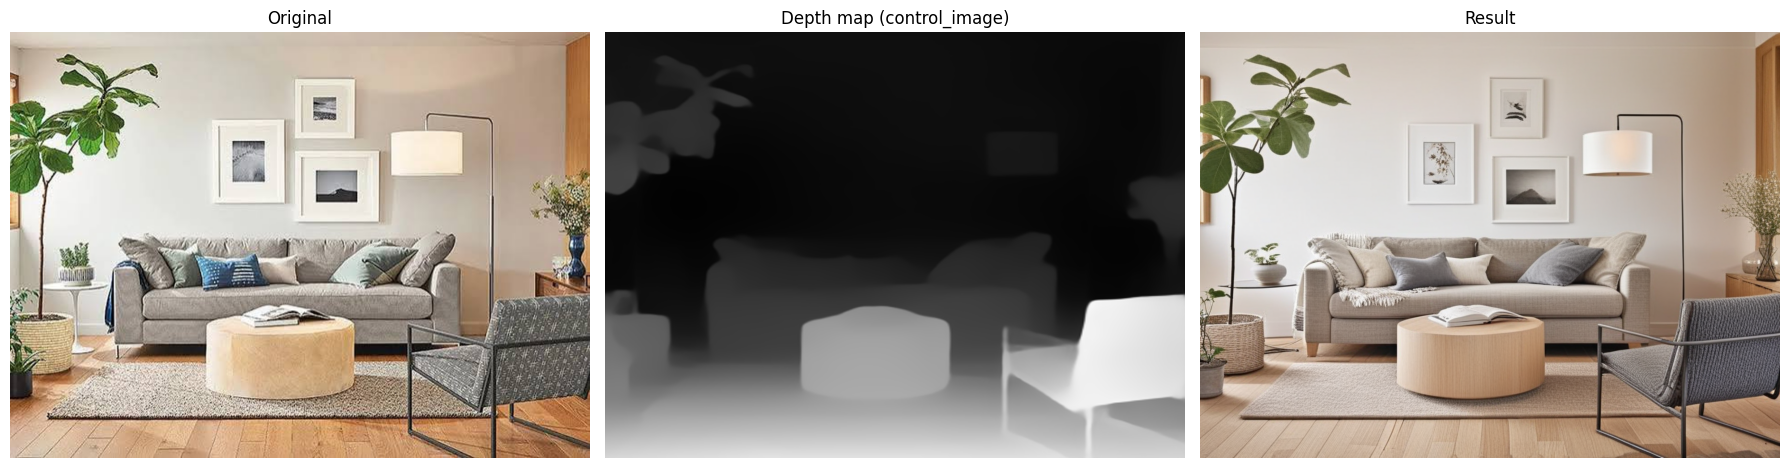

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(original_image.resize((GEN_W, GEN_H)))
axes[0].set_title("Original")
axes[1].imshow(depth_map)
axes[1].set_title("Depth map (control_image)")
axes[2].imshow(result)
axes[2].set_title("Result")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()